# COSMOS: Time Scale vs Simulation Timestep

## Research Question

How does COSMOS's `time_scale` affect the simulation
timestep, and how does increasing the timestep affect
simulation accuracy and energy conservation?

## Hypothesis

Because COSMOS currently calculates:

sim_dt = dt × time_scale

increasing `time_scale` should increase the simulation
timestep proportionally.

Larger timesteps may introduce greater numerical error,
which may appear as increased variation or drift in the
system's total mechanical energy.

# COSMOS: Time Scale, Timestep & Simulation Reliability

## Research Goal

The goal of this research is to determine how COSMOS's simulation time scale and numerical integration timestep affect the **accuracy, stability, and trustworthiness** of its orbital simulations.

COSMOS currently advances simulation time according to the relationship:

$$
\Delta t_{\text{sim}} = \Delta t_{\text{real}} \times \text{time\_scale}
$$

This means that increasing the simulation time scale also increases the timestep supplied to the numerical integrator.

The purpose of this research is to understand the consequences of this relationship rather than immediately modifying the implementation.

### Ultimately, this research aims to determine:

- How `time_scale` affects the numerical timestep.
- How timestep size affects numerical accuracy.
- How timestep size affects total mechanical energy conservation.
- How timestep size affects orbital behaviour and stability.
- How the Velocity Verlet integrator behaves across different timestep sizes.
- Whether there are practical timestep limits for reliable COSMOS simulations.
- Whether simulation speed and numerical timestep should eventually be separated.
- Whether techniques such as fixed timesteps or substepping could allow COSMOS to advance simulated time faster while maintaining acceptable numerical accuracy.

## Final Research Question

> **How can COSMOS advance simulated time efficiently while maintaining a level of numerical accuracy and stability sufficient for scientifically trustworthy orbital simulations?**

The research will use theoretical analysis, controlled computational experiments, measured simulation data, and graphical analysis to answer this question.

The objective is not simply to make COSMOS run faster.

The objective is to understand **when COSMOS can be trusted, why it can be trusted, and what conditions are required for that trust to remain justified.**

## 1. Numerical Timestep

### Definition

A numerical timestep is the amount of simulated time
advanced by a numerical integration method in one step.

### COSMOS Implementation

COSMOS currently calculates its simulation timestep as:

$$
\Delta t_{\text{sim}} =
\Delta t_{\text{real}} \times \text{time\_scale}
$$

### Importance

The timestep determines how far the numerical integrator
advances the physical system during each integration step.
Because numerical integration approximates continuous
physical evolution using discrete steps, timestep size can
affect both computational cost and numerical accuracy.

## 2. Experiment 1: Time Scale and Simulation Timestep

The current COSMOS implementation calculates the simulation
timestep using the real-world frame timestep and the selected
time scale:

$$
\Delta t_{\text{sim}} =
\Delta t_{\text{real}} \times \text{time\_scale}
$$

The purpose of this experiment is to observe how the
simulation timestep changes as `time_scale` increases.

We will initially assume a target frame rate of 60 FPS,
giving an approximate real-world timestep of:

$$
\Delta t_{\text{real}} = \frac{1}{60}\text{ s}
$$

The experiment will then calculate the corresponding
simulation timestep for a range of time scales.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
fps = 60
dt_real = 1 / fps

time_scales = np.array([
    1,
    2,
    5,
    10,
    20,
    40,
    80,
    100,
    200,
])
sim_dt = dt_real * time_scales

In [3]:
data = pd.DataFrame({
    "Time Scale": time_scales,
    "Real dt (s)": dt_real,
    "Simulation dt (s)": sim_dt,
})

data

,Time Scale,Real dt (s),Simulation dt (s)
0,1,0.016667,0.016667
1,2,0.016667,0.033333
2,5,0.016667,0.083333
3,10,0.016667,0.166667
4,20,0.016667,0.333333
5,40,0.016667,0.666667
6,80,0.016667,1.333333
7,100,0.016667,1.666667
8,200,0.016667,3.333333


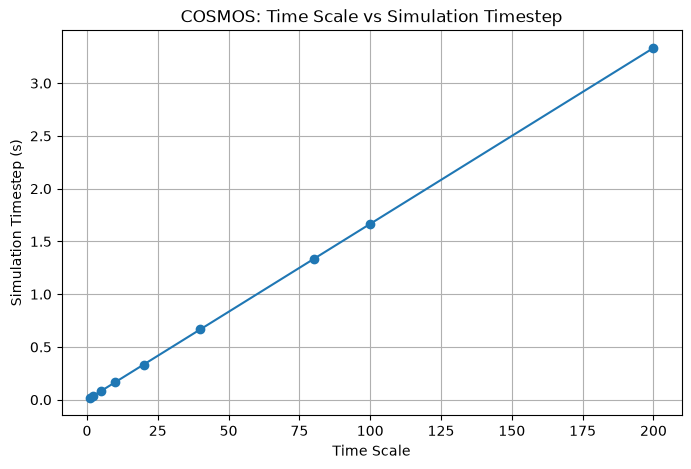

In [4]:
plt.figure(figsize=(8, 5))

plt.plot(
    time_scales,
    sim_dt,
    marker="o",
)

plt.xlabel("Time Scale")
plt.ylabel("Simulation Timestep (s)")
plt.title("COSMOS: Time Scale vs Simulation Timestep")
plt.grid(True)

plt.show()

## 2.1 Conclusion: Time Scale and Simulation Timestep

The experiment confirms that, under the current COSMOS implementation, the simulation timestep is directly proportional to the selected `time_scale`.

The relationship is:

$$
\Delta t_{\text{sim}} =
\Delta t_{\text{real}} \times \text{time\_scale}
$$

Using an idealized frame rate of 60 FPS, the real-world timestep was assumed to be approximately:

$$
\Delta t_{\text{real}} = \frac{1}{60} \approx 0.016667\text{ s}
$$

The results showed that increasing `time_scale` increases the simulation timestep proportionally. For example:

- `time_scale = 1` produces a timestep of approximately `0.016667 s`.
- `time_scale = 80` produces a timestep of approximately `1.333333 s`.
- `time_scale = 200` produces a timestep of approximately `3.333333 s`.

Therefore, the current COSMOS implementation does not simply make simulation time progress faster when `time_scale` is increased. It also increases the size of each numerical integration step.

### Limitation

This experiment used an assumed constant frame rate of 60 FPS. COSMOS does not necessarily maintain 60 FPS during runtime, meaning that the actual `dt_real` can vary between frames.

Therefore, this experiment establishes the **theoretical relationship** between `time_scale` and `sim_dt`, but it does not yet describe the exact runtime behaviour of COSMOS.

The next experiment will investigate how actual FPS and frame-to-frame `dt_real` affect the simulation timestep.